In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
import warnings

warnings.filterwarnings("ignore")

# 🟢 1. Define the 30-Stock Portfolio & Dates (Updated to April 2026)
TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "META", # Tech
    "JPM", "V", "BAC", "MA", "WFC",          # Finance
    "JNJ", "UNH", "LLY", "ABBV", "MRK",      # Healthcare
    "AMZN", "WMT", "PG", "HD", "COST",       # Consumer
    "XOM", "CVX", "CAT", "GE", "UNP",        # Industrials/Energy
    "TMUS", "VZ", "NEE", "DUK", "SO"         # Telecom/Utils
]

START_DATE = "2010-01-01"
END_DATE = "2026-04-20"  # Up to the latest market day

# 🟢 2. Download and process the S&P 500 Benchmark (SPY) first
print("📥 Downloading S&P 500 (SPY) Benchmark...")
spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)

spy.reset_index(inplace=True)
spy['spy_return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy['spy_volatility_20d'] = spy['spy_return'].rolling(20).std()

# Keep only what we need to merge
spy_features = spy[['Date', 'spy_return', 'spy_volatility_20d']].dropna()

# 🟢 3. Download the 30 Stocks and Merge the Macro Data
print(f"📥 Downloading data for {len(TICKERS)} stocks and merging macro features...")
dataset_list = []

for ticker in TICKERS:
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
            
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        df.reset_index(inplace=True)
        df['asset'] = ticker
        
        # Base Features
        df['target_return'] = np.log(df['Close'] / df['Close'].shift(1))
        df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()
        
        macd_inst = ta.trend.MACD(df['Close'], window_fast=12, window_slow=26, window_sign=9)
        df['MACD'] = macd_inst.macd()
        df['MACD_Signal'] = macd_inst.macd_signal()
        df['ATR'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close'], window=14).average_true_range()
        
        # 🟢 4. Merge SPY data onto this specific stock using the exact Date
        df = pd.merge(df, spy_features, on='Date', how='inner')
        
        # 🟢 5. Calculate rolling correlation between this stock and the S&P 500
        df['asset_to_spy_correlation'] = df['target_return'].rolling(window=20).corr(df['spy_return'])
        
        df.dropna(inplace=True)
        dataset_list.append(df)
        
    except Exception as e:
        print(f"⚠️ Failed to process {ticker}: {e}")

# Combine everything
final_df = pd.concat(dataset_list, ignore_index=True)

# Reorder columns
FINAL_COLUMNS = [
    'Date', 'asset', 'target_return', 'Close', 'High', 'Low', 'Open', 'Volume', 
    'RSI', 'MACD', 'MACD_Signal', 'ATR', 
    'spy_return', 'spy_volatility_20d', 'asset_to_spy_correlation'
]
final_df = final_df[FINAL_COLUMNS]

filename = "stock_market_final_30_macro.csv"
final_df.to_csv(filename, index=False)

print("\n" + "="*50)
print(f"✅ DATASET CREATED SUCCESSFULLY!")
print(f"📊 Total Rows: {len(final_df)}")
print(f"📁 Saved as: {filename}")
print("="*50)

📥 Downloading S&P 500 (SPY) Benchmark...
📥 Downloading data for 30 stocks and merging macro features...

✅ DATASET CREATED SUCCESSFULLY!
📊 Total Rows: 120399
📁 Saved as: stock_market_final_30_macro.csv


In [18]:
# --- STEP 1 (Corrected): IMPORTS & CONFIGURATION ---

import pandas as pd
import numpy as np
import warnings
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting import (
    TimeSeriesDataSet,
    GroupNormalizer,
    NaNLabelEncoder,
    TemporalFusionTransformer,
    RMSE,
    MAE
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os
import shutil
# (Add this import at the top with your other imports)
from lightning.pytorch.callbacks import ModelCheckpoint
from sklearn.preprocessing import RobustScaler

# Suppress ignorable warnings
warnings.filterwarnings("ignore", "is_categorical_dtype is deprecated", UserWarning)

# ============================================================================
# --- MODEL & FEATURE CONFIGURATION ---
# ============================================================================

# Our champion model's configuration
MAX_ENCODER_LENGTH = 60
HIDDEN_SIZE = 128
ATTENTION_HEAD_SIZE = 4
BATCH_SIZE = 64
MAX_EPOCHS = 50
max_prediction_length = 1 # We are always predicting 1 day ahead

# This is our new, upgraded feature list
# This is our new, upgraded feature list
# This is our continuously growing feature list!
# The final, ultimate feature list!
# The final, ultimate feature list!
FEATURES = [
    "Close", "High", "Low", "Open", "Volume",
    "RSI", "MACD", "MACD_Signal", "ATR",
    "returns", "volatility_20d", "momentum_5d", 
    "ma_7d", "ma_21d", "ma_crossover",
    
    # Lag & Momentum
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5", "return_lag_10", "return_lag_20",
    "roc_5", "roc_10", "roc_20",
    "stoch_k", "williams_r",
    
    # Volatility & Volume
    "bb_position", "hist_vol_20", 
    "volume_ratio", "obv",
    
    # Cyclical Time Encoding
    "day_sin", "day_cos", "month_sin", "month_cos",

    # 🟢 NEW: The official clipped target variable!
    "target_clipped"
]

# --- (THIS IS THE FIX) Define Walk-Forward Folds based on your date range ---
# We will test on ~1 year of data at a time
# FOLDS = [
#     {"name": "Fold 1", "train_end": pd.to_datetime("2021-08-31"), "test_end": pd.to_datetime("2022-08-31")},
#     {"name": "Fold 2", "train_end": pd.to_datetime("2022-08-31"), "test_end": pd.to_datetime("2023-08-31")},
#     {"name": "Fold 3", "train_end": pd.to_datetime("2023-08-31"), "test_end": pd.to_datetime("2024-08-31")},
#     {"name": "Fold 4", "train_end": pd.to_datetime("2024-08-31"), "test_end": pd.to_datetime("2025-08-27")}, # Test to the end of your data
# ]
# Updated for the 2010-2024 Dataset
FOLDS = [
    {"name": "Fold 1", "train_end": pd.to_datetime("2023-12-31"), "test_end": pd.to_datetime("2024-12-31")},
    {"name": "Fold 2", "train_end": pd.to_datetime("2024-12-31"), "test_end": pd.to_datetime("2025-12-31")},
    {"name": "Fold 3", "train_end": pd.to_datetime("2025-12-31"), "test_end": pd.to_datetime("2026-04-20")},
]

# Store results here
all_fold_results = []



# (Add this at the end of Step 1, after all_fold_results = [])
# This callback will save our FINAL model from the last fold
final_model_checkpoint = ModelCheckpoint(
    monitor="val_loss",
    dirpath=".",  # Save directly in the current folder
    filename="champion_model_trial_2",  # This will be the saved file name
    save_top_k=1,
    mode="min",
)
print("✅ Step 1 Complete: Configuration loaded (with ModelCheckpoint).")

✅ Step 1 Complete: Configuration loaded (with ModelCheckpoint).


In [28]:
# --- STEP 2: LOAD BASE DATASET ---

print("Loading base dataset 'stock_market_final_30_macro.csv'...")
try:
    df_base = pd.read_csv('stock_market_final_30_macro.csv')
    
    # 🟢 FIX: Ensure we explicitly keep the macro columns when loading!
    df_base = df_base[['Date', 'asset', 'target_return', 'Close', 'High', 'Low', 'Open', 'Volume', 
                       'RSI', 'MACD', 'MACD_Signal', 'ATR', 
                       'spy_return', 'spy_volatility_20d', 'asset_to_spy_correlation']]
    
    df_base['Date'] = pd.to_datetime(df_base['Date'])
    print(f"✅ Successfully loaded {len(df_base)} rows.")
except FileNotFoundError:
    print("❌ Error: 'stock_market_final_30_macro.csv' not found.")

Loading base dataset 'stock_market_final_30_macro.csv'...
✅ Successfully loaded 120399 rows.


In [30]:
# # --- STEP 3 (Corrected): RUN WALK-FORWARD VALIDATION LOOP ---

# print("Starting Walk-Forward Validation...")

# for fold in FOLDS:
#     print("\n" + "="*70)
#     print(f"STARTING: {fold['name']} | Train up to {fold['train_end'].date()} | Test on {fold['test_end'].year}")
#     print("="*70)

#     # --- 3a. Create datasets for this fold ---
#     print(f"[{fold['name']}] 1/6: Creating datasets...")
    
#     df_fold = df_base.copy()
    
#     # --- Feature Engineering ---
#     # --- Feature Engineering ---
#     gb = df_fold.groupby('asset')
#     df_fold['returns'] = gb['Close'].transform(lambda x: x.pct_change())
#     df_fold['volatility_20d'] = gb['returns'].transform(lambda x: x.rolling(20).std())
#     df_fold['momentum_5d'] = gb['Close'].transform(lambda x: x.pct_change(5))
#     df_fold['ma_7d'] = gb['Close'].transform(lambda x: x.rolling(7).mean())
#     df_fold['ma_21d'] = gb['Close'].transform(lambda x: x.rolling(21).mean())
#     df_fold['ma_crossover'] = (df_fold['ma_7d'] - df_fold['ma_21d']) / df_fold['Close']
    
#     # 🟢 NEW: Lagged Returns (Autoregressive features)
#     for lag in [1, 2, 3, 5, 10, 20]:
#         df_fold[f'return_lag_{lag}'] = gb['target_return'].shift(lag)
        
#     # 🟢 NEW: Rate of Change (ROC)
#     for period in [5, 10, 20]:
#         df_fold[f'roc_{period}'] = gb['Close'].transform(lambda x: x.pct_change(periods=period))
        
#     # 🟢 NEW: Stochastic Oscillator & Williams %R (14-day lookback)
#     high_14 = gb['High'].transform(lambda x: x.rolling(14).max())
#     low_14 = gb['Low'].transform(lambda x: x.rolling(14).min())
    
#     df_fold['stoch_k'] = (df_fold['Close'] - low_14) / (high_14 - low_14 + 1e-8) * 100
#     df_fold['williams_r'] = (high_14 - df_fold['Close']) / (high_14 - low_14 + 1e-8) * -100

#     # Drop NaNs created by rolling windows & lags
#     # ... (Your previous Momentum and Lag code is here) ...

#     # 🟢 NEW: Volatility Regime Features
#     rolling_mean = gb['Close'].transform(lambda x: x.rolling(20).mean())
#     rolling_std = gb['Close'].transform(lambda x: x.rolling(20).std())
    
#     # Where is the price relative to Bollinger Bands? (0 = bottom band, 1 = top band)
#     df_fold['bb_position'] = (df_fold['Close'] - (rolling_mean - 2 * rolling_std)) / (4 * rolling_std + 1e-8)
    
#     # Annualized Historical Volatility
#     df_fold['hist_vol_20'] = gb['target_return'].transform(lambda x: x.rolling(20).std() * np.sqrt(252))

#     # 🟢 NEW: Volume Features
#     # Is today's volume unusually high?
#     df_fold['volume_ratio'] = df_fold['Volume'] / (gb['Volume'].transform(lambda x: x.rolling(20).mean()) + 1e-8)
    
#     # On-Balance Volume (Cumulative buying vs selling pressure)
#     df_fold['obv'] = gb.apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).cumsum()).reset_index(level=0, drop=True)

#     # Drop NaNs created by rolling windows & lags
#     # ... (Your previous Volume code is here) ...

#     # 🟢 NEW: Cyclical Time Encoding (Seasonality & Day Effects)
#     df_fold['day_sin'] = np.sin(2 * np.pi * df_fold['Date'].dt.dayofweek / 5)
#     df_fold['day_cos'] = np.cos(2 * np.pi * df_fold['Date'].dt.dayofweek / 5)
    
#     df_fold['month_sin'] = np.sin(2 * np.pi * df_fold['Date'].dt.month / 12)
#     df_fold['month_cos'] = np.cos(2 * np.pi * df_fold['Date'].dt.month / 12)

#     # Drop NaNs created by rolling windows & lags
#     from sklearn.preprocessing import RobustScaler

#     # ... (Your previous Cyclical Time Encoding code is here) ...

#     # 🟢 NEW: Target Engineering (Clipping Outliers)
#     # We clip the top 1% and bottom 1% of extreme moves to prevent the model from chasing noise
#     df_fold['target_clipped'] = gb['target_return'].transform(
#         lambda x: x.clip(x.quantile(0.01), x.quantile(0.99))
#     )

#     # 🟢 NEW: Data Preprocessing (Robust Scaler Per Asset)
#     # List of all continuous features that need to be scaled
#     features_to_scale = [
#         "Close", "High", "Low", "Open", "Volume",
#         "RSI", "MACD", "MACD_Signal", "ATR",
#         "volatility_20d", "momentum_5d", "ma_7d", "ma_21d", "ma_crossover",
#         "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5", "return_lag_10", "return_lag_20",
#         "roc_5", "roc_10", "roc_20", "stoch_k", "williams_r",
#         "bb_position", "hist_vol_20", "volume_ratio", "obv"
#     ]

#     # Apply RobustScaler individually to each asset (AAPL, TSLA, etc.)
#     for asset in df_fold['asset'].unique():
#         scaler = RobustScaler()
#         mask = df_fold['asset'] == asset
#         df_fold.loc[mask, features_to_scale] = scaler.fit_transform(df_fold.loc[mask, features_to_scale])

#     # Finally, drop NaNs created by rolling windows & lags
#     df_fold = df_fold.dropna().reset_index(drop=True)
    
#     # --- Time features ---
#     df_fold['time_idx'] = df_fold.groupby('asset').cumcount()
#     df_fold['month'] = df_fold['Date'].dt.month.astype(str).astype("category")
#     df_fold['day_of_week'] = df_fold['Date'].dt.dayofweek.astype(str).astype("category")
#     df_fold['asset'] = df_fold['asset'].astype("category")
#     df_fold['Volume'] = df_fold['Volume'].astype(float)
    
#     # --- Splitting by Date ---
#     train_df = df_fold[df_fold['Date'] <= fold['train_end']]
#     test_df = df_fold[(df_fold['Date'] > fold['train_end']) & (df_fold['Date'] <= fold['test_end'])]
    
#     # Scalers
#     scalers = {col: GroupNormalizer(groups=["asset"], method="robust") for col in FEATURES}

#     # Create training dataset
#     training_data = TimeSeriesDataSet(
#         train_df, time_idx="time_idx", target="target_clipped", group_ids=["asset"],
#         max_encoder_length=MAX_ENCODER_LENGTH, max_prediction_length=max_prediction_length,
#         static_categoricals=["asset"], time_varying_known_categoricals=["month", "day_of_week"],
#         time_varying_unknown_reals=FEATURES,
#         target_normalizer=GroupNormalizer(
#         groups=["asset"], 
#         transformation="standard", 
#         center=True
#         ),
#         categorical_encoders={"month": NaNLabelEncoder(add_nan=True), "day_of_week": NaNLabelEncoder(add_nan=True)}
#     )

#     # Create validation (test) dataset for this fold
#     validation_data = TimeSeriesDataSet.from_dataset(
#         training_data, test_df, predict=False, stop_randomization=True
#     )
    
#     # Check for empty data
#     if len(validation_data) == 0 or len(training_data) == 0:
#         print(f"⚠️ {fold['name']} skipped: No data in train/test period.")
#         continue
    
#     train_dataloader = training_data.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
#     val_dataloader = validation_data.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
    
#     print(f"✅ Datasets created. Train samples: {len(training_data)} | Test samples: {len(validation_data)}")

#     # --- 3b. Configure Model & Trainer ---
#     print(f"[{fold['name']}] 2/6: Configuring model...")
    
#     # Define callbacks
#     early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    
#     # Add our new checkpoint callback, BUT only on the last fold
#     fold_callbacks = [early_stop_callback]
#     if fold['name'] == FOLDS[-1]['name']: # Check if it's the last fold
#         fold_callbacks.append(final_model_checkpoint)
    
#     # Define ONE trainer
#     trainer = pl.Trainer(
#     max_epochs=100,             # Increased to 100 for deeper learning
#     accelerator="auto",         
#     gradient_clip_val=0.5,      # Increased to 0.5 to safely handle the new volatility data
#     callbacks=[early_stop_callback, checkpoint_callback],
#     enable_model_summary=False
#     )

#     # Define the model
#     tft = TemporalFusionTransformer.from_dataset(
#     training,
#     learning_rate=0.001,        # Lowered learning rate for stable, careful learning
#     hidden_size=160,            # MASSIVE UPGRADE (Increased from 16 to 160)
#     attention_head_size=4,      # 4 attention heads to focus on different timeframes
#     dropout=0.1,                # Regularization to prevent memorizing the past
#     hidden_continuous_size=32,  # Upgraded to process complex continuous numbers
#     loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]), # Predicts the worst/best case bounds
#     optimizer="adam",           # Keep Adam!
#     reduce_on_plateau_patience=4
#     )
#     print(f"✅ Model configured (h={HIDDEN_SIZE}, heads={ATTENTION_HEAD_SIZE}).")
    
#     # --- 3c. Find Learning Rate ---
#     print(f"[{fold['name']}] 3/6: Finding learning rate...")
#     tuner = Tuner(trainer)
#     lr_finder = tuner.lr_find(
#         tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader,
#         max_lr=1.0, min_lr=1e-5, early_stop_threshold=1000.0
#     )
#     suggested_lr = lr_finder.suggestion()
#     if suggested_lr is None: suggested_lr = 1e-3
#     tft.hparams.learning_rate = suggested_lr
#     print(f"✅ LR set to {suggested_lr:.6f}")

#     # --- 3d. Train Model ---
#     print(f"[{fold['name']}] 4/6: Training model... (This will take a few minutes)")
#     trainer.fit(
#         tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader,
#     )
    
#     # --- 3e. Load Best Model & Predict ---
#     print(f"[{fold['name']}] 5/6: Loading best model and predicting...")
#     best_model_path = trainer.checkpoint_callback.best_model_path
#     best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
    
#     # We MUST use return_x=True for the index to be returned correctly
#     prediction_output = best_tft.predict(
#         validation_data,
#         return_index=True,
#         return_x=True  # <-- This is correct
#     )
    
#     # Unpack the tuple
#     raw_predictions = prediction_output[0]
#     val_index = prediction_output[1]
    
#     predictions = raw_predictions.numpy().flatten()
#     actuals = np.concatenate([y[0] for x, y in iter(val_dataloader)]).flatten()
    
#     # --- 3f. Calculate Metrics for this Fold ---
#     print(f"[{fold['name']}] 6/6: Calculating metrics...")
    
#     asset_indices = val_index['groups'].numpy().flatten()
#     asset_names = validation_data.categorical_encoders['asset'].inverse_transform(asset_indices)
#     time_idx = val_index['decoder_time_idx'].numpy().flatten()

#     results_df = pd.DataFrame({
#         'asset': asset_names, 'time_idx': time_idx,
#         'actual_return': actuals, 'predicted_return': predictions
#     })

#     results_df['actual_direction'] = np.sign(results_df['actual_return'])
#     results_df['predicted_direction'] = np.sign(results_df['predicted_return'])
#     results_df['correct_direction'] = (results_df['actual_direction'] == results_df['predicted_direction']).astype(int)
#     non_zero_mask = (results_df['actual_direction'] != 0) & (results_df['predicted_direction'] != 0)

#     fold_mae = mean_absolute_error(actuals, predictions)
#     fold_rmse = np.sqrt(mean_squared_error(actuals, predictions))
#     fold_hit_rate = results_df[non_zero_mask]['correct_direction'].mean()
    
#     print(f"✅ {fold['name']} Complete! Hit Rate: {fold_hit_rate * 100:.2f}%")
    
#     # Store results
#     all_fold_results.append({
#         "Fold": fold['name'], "Train Period": f"2013-{fold['train_end'].year}",
#         "Test Period": f"{fold['test_end'].year}", "Hit Rate (%)": fold_hit_rate * 100,
#         "MAE": fold_mae, "RMSE": fold_rmse, "Test Samples": len(validation_data)
#     })
    
#     # Clean up checkpoint files, BUT NOT for the last fold
#     if fold['name'] != FOLDS[-1]['name']:
#         try:
#             log_dir = "lightning_logs"
#             if os.path.isdir(log_dir): shutil.rmtree(log_dir)
#             lr_ckpt = [f for f in os.listdir(".") if f.startswith(".lr_find") and f.endswith(".ckpt")]
#             for f in lr_ckpt: os.remove(f)
#         except Exception as e:
#             print(f"Warning: Could not clean up checkpoint files: {e}")
#     else:
#         print(f"✅ Preserving 'lightning_logs' for final saved model.")

# print("\n🎉 --- STEP 3 COMPLETE: ALL FOLDS TRAINED --- 🎉")
# --- STEP 3 (Corrected & Upgraded): RUN WALK-FORWARD VALIDATION LOOP ---
# --- STEP 3: RUN WALK-FORWARD VALIDATION LOOP (WITH DYNAMIC LR TUNER) ---

# --- STEP 3: RUN WALK-FORWARD VALIDATION LOOP (FINAL) ---

import os
import shutil
import warnings
import numpy as np
import pandas as pd
import lightning.pytorch as pl

# 🟢 THE NUCLEAR OPTION: Completely disable all TQDM widgets at the system level
# This ensures the LR Tuner runs silently without freezing Jupyter
os.environ['TQDM_DISABLE'] = '1'

# 🟢 Hide annoying Pandas & Lightning warnings for a clean console
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="lightning.pytorch.utilities.parsing")
warnings.filterwarnings("ignore", module="lightning.pytorch.callbacks.model_checkpoint")

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer, NaNLabelEncoder, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler

# 🟢 Clean text-based progress tracker
class SimpleTextProgress(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get('val_loss')
        v_loss_str = f"{val_loss.item():.5f}" if val_loss is not None else "Pending..."
        if trainer.current_epoch % 5 == 0 or trainer.current_epoch == trainer.max_epochs - 1:
            print(f"   ⏳ Epoch {trainer.current_epoch:02d} Complete | Val Loss: {v_loss_str}")

print("Starting Walk-Forward Validation...")

for fold in FOLDS:
    print("\n" + "="*70)
    print(f"STARTING: {fold['name']} | Train up to {fold['train_end'].date()} | Test on {fold['test_end'].year}")
    print("="*70)

    # --- 3a. Create datasets for this fold ---
    print(f"[{fold['name']}] 1/6: Creating datasets & engineering features...")
    
    df_fold = df_base.copy()
    
    # --- Feature Engineering ---
    gb = df_fold.groupby('asset')
    df_fold['returns'] = gb['Close'].transform(lambda x: x.pct_change())
    df_fold['volatility_20d'] = gb['returns'].transform(lambda x: x.rolling(20).std())
    df_fold['momentum_5d'] = gb['Close'].transform(lambda x: x.pct_change(5))
    df_fold['ma_7d'] = gb['Close'].transform(lambda x: x.rolling(7).mean())
    df_fold['ma_21d'] = gb['Close'].transform(lambda x: x.rolling(21).mean())
    df_fold['ma_crossover'] = (df_fold['ma_7d'] - df_fold['ma_21d']) / df_fold['Close']
    
    # Lagged Returns (Autoregressive features)
    for lag in [1, 2, 3, 5, 10, 20]:
        df_fold[f'return_lag_{lag}'] = gb['target_return'].shift(lag)
        
    # Rate of Change (ROC)
    for period in [5, 10, 20]:
        df_fold[f'roc_{period}'] = gb['Close'].transform(lambda x: x.pct_change(periods=period))
        
    # Stochastic Oscillator & Williams %R
    high_14 = gb['High'].transform(lambda x: x.rolling(14).max())
    low_14 = gb['Low'].transform(lambda x: x.rolling(14).min())
    df_fold['stoch_k'] = (df_fold['Close'] - low_14) / (high_14 - low_14 + 1e-8) * 100
    df_fold['williams_r'] = (high_14 - df_fold['Close']) / (high_14 - low_14 + 1e-8) * -100

    # Volatility Regime Features
    rolling_mean = gb['Close'].transform(lambda x: x.rolling(20).mean())
    rolling_std = gb['Close'].transform(lambda x: x.rolling(20).std())
    df_fold['bb_position'] = (df_fold['Close'] - (rolling_mean - 2 * rolling_std)) / (4 * rolling_std + 1e-8)
    df_fold['hist_vol_20'] = gb['target_return'].transform(lambda x: x.rolling(20).std() * np.sqrt(252))

    # Volume Features
    df_fold['volume_ratio'] = df_fold['Volume'] / (gb['Volume'].transform(lambda x: x.rolling(20).mean()) + 1e-8)
    df_fold['obv'] = gb.apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).cumsum(), include_groups=False).reset_index(level=0, drop=True)

    # Cyclical Time Encoding
    df_fold['day_sin'] = np.sin(2 * np.pi * df_fold['Date'].dt.dayofweek / 5)
    df_fold['day_cos'] = np.cos(2 * np.pi * df_fold['Date'].dt.dayofweek / 5)
    df_fold['month_sin'] = np.sin(2 * np.pi * df_fold['Date'].dt.month / 12)
    df_fold['month_cos'] = np.cos(2 * np.pi * df_fold['Date'].dt.month / 12)

    # Target Engineering (Clipping Outliers)
    df_fold['target_clipped'] = gb['target_return'].transform(
        lambda x: x.clip(x.quantile(0.01), x.quantile(0.99))
    )

    KNOWN_REALS = ["time_idx", "day_sin", "day_cos", "month_sin", "month_cos"]
    UNKNOWN_REALS = [
        "Close", "High", "Low", "Open", "Volume",
        "RSI", "MACD", "MACD_Signal", "ATR",
        "volatility_20d", "momentum_5d", "ma_7d", "ma_21d", "ma_crossover",
        "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5", "return_lag_10", "return_lag_20",
        "roc_5", "roc_10", "roc_20", "stoch_k", "williams_r",
        "bb_position", "hist_vol_20", "volume_ratio", "obv",
        "spy_return", "spy_volatility_20d", "asset_to_spy_correlation" # 🟢 Added Macro Features!
    ]

    # Ensure all data is float before scaling to prevent dtype warnings
    df_fold[UNKNOWN_REALS] = df_fold[UNKNOWN_REALS].astype(float)

    # Data Preprocessing (Robust Scaler Per Asset)
    for asset in df_fold['asset'].unique():
        scaler = RobustScaler()
        mask = df_fold['asset'] == asset
        df_fold.loc[mask, UNKNOWN_REALS] = scaler.fit_transform(df_fold.loc[mask, UNKNOWN_REALS])

    # Drop NaNs created by rolling windows & lags
    df_fold = df_fold.dropna().reset_index(drop=True)
    
    # --- Time features ---
    df_fold['time_idx'] = df_fold.groupby('asset').cumcount()
    df_fold['month'] = df_fold['Date'].dt.month.astype(str).astype("category")
    df_fold['day_of_week'] = df_fold['Date'].dt.dayofweek.astype(str).astype("category")
    df_fold['asset'] = df_fold['asset'].astype("category")
    df_fold['Volume'] = df_fold['Volume'].astype(float)
    
    # --- Splitting by Date ---
    train_df = df_fold[df_fold['Date'] <= fold['train_end']]
    test_df = df_fold[(df_fold['Date'] > fold['train_end']) & (df_fold['Date'] <= fold['test_end'])]
    
    # Create training dataset
    training_data = TimeSeriesDataSet(
        train_df, 
        time_idx="time_idx", 
        target="target_clipped", 
        group_ids=["asset"],
        max_encoder_length=MAX_ENCODER_LENGTH, 
        max_prediction_length=max_prediction_length,
        static_categoricals=["asset"], 
        time_varying_known_categoricals=["month", "day_of_week"],
        time_varying_known_reals=KNOWN_REALS,      
        time_varying_unknown_reals=UNKNOWN_REALS,  
        target_normalizer=GroupNormalizer(
            groups=["asset"], 
            method="standard",    
            transformation=None,  
            center=True
        ),
        categorical_encoders={"month": NaNLabelEncoder(add_nan=True), "day_of_week": NaNLabelEncoder(add_nan=True)},
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    # Create validation dataset
    validation_data = TimeSeriesDataSet.from_dataset(
        training_data, test_df, predict=False, stop_randomization=True
    )
    
    if len(validation_data) == 0 or len(training_data) == 0:
        print(f"⚠️ {fold['name']} skipped: No data in train/test period.")
        continue
    
    train_dataloader = training_data.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
    val_dataloader = validation_data.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
    
    print(f"✅ Datasets created. Train samples: {len(training_data)} | Test samples: {len(validation_data)}")

    # --- 3b. Configure Model & Trainer ---
    print(f"[{fold['name']}] 2/6: Configuring model...")
    
    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    checkpoint_callback = ModelCheckpoint(dirpath="checkpoints", filename=f"tft_{fold['name']}", save_top_k=1, monitor="val_loss", mode="min")
    
    fold_callbacks = [early_stop_callback, checkpoint_callback, SimpleTextProgress()]
    
    trainer = pl.Trainer(
        max_epochs=100,             
        accelerator="auto",         
        gradient_clip_val=1.0,      
        callbacks=fold_callbacks,
        enable_model_summary=False,
        enable_progress_bar=False
    )

    tft = TemporalFusionTransformer.from_dataset(
        training_data,
        learning_rate=0.001,        # Baseline LR (Tuner will overwrite this)
        hidden_size=160,            
        attention_head_size=4,      
        dropout=0.15,                
        hidden_continuous_size=32,  
        loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]), 
        optimizer="adam",           
        reduce_on_plateau_patience=4
    )
    print(f"✅ Model configured (h=160, heads=4).")

    # --- 3c. Find Learning Rate ---
    print(f"[{fold['name']}] 3/6: Finding optimal learning rate...")
    tuner = Tuner(trainer)
    lr_finder = tuner.lr_find(
        tft, 
        train_dataloaders=train_dataloader, 
        val_dataloaders=val_dataloader,
        max_lr=1.0, 
        min_lr=1e-5, 
        early_stop_threshold=1000.0
    )
    
    suggested_lr = lr_finder.suggestion()
    if suggested_lr is None: 
        suggested_lr = 1e-3
        print(f"   ⚠️ Tuner failed to find distinct minimum, defaulting to {suggested_lr}")
    else:
        print(f"   ✅ Learning Rate dynamically set to: {suggested_lr:.6f}")
        
    tft.hparams.learning_rate = suggested_lr

    # --- 3d. Train Model ---
    print(f"[{fold['name']}] 4/6: Training model... (This will take a few minutes)")
    trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
    
    # --- 3e. Load Best Model & Predict ---
    print(f"[{fold['name']}] 5/6: Loading best model and predicting...")
    best_model_path = trainer.checkpoint_callback.best_model_path
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
    
    # 🟢 FIX: Removed the invalid 'show_progress_bar' argument
    prediction_output = best_tft.predict(
        val_dataloader,
        mode="quantiles", 
        return_index=True,
        return_y=True,    
        trainer_kwargs=dict(accelerator="auto", enable_progress_bar=False)
    )
    
    predictions = prediction_output.output[:, :, 1].cpu().flatten().numpy()
    actuals = prediction_output.y[0].cpu().flatten().numpy()
    val_index = prediction_output.index
    
    # --- 3f. Calculate Metrics for this Fold ---
    print(f"[{fold['name']}] 6/6: Calculating metrics...")
    
    # PyTorch Forecasting index object is a pandas DataFrame
    results_df = pd.DataFrame({
        'asset': val_index['asset'], 
        'time_idx': val_index['time_idx'],
        'actual_return': actuals, 
        'predicted_return': predictions
    })

    results_df['actual_direction'] = np.sign(results_df['actual_return'])
    results_df['predicted_direction'] = np.sign(results_df['predicted_return'])
    results_df['correct_direction'] = (results_df['actual_direction'] == results_df['predicted_direction']).astype(int)
    non_zero_mask = (results_df['actual_direction'] != 0) & (results_df['predicted_direction'] != 0)

    fold_mae = mean_absolute_error(actuals, predictions)
    fold_rmse = np.sqrt(mean_squared_error(actuals, predictions))
    fold_hit_rate = results_df[non_zero_mask]['correct_direction'].mean()
    
    print(f"✅ {fold['name']} Complete! Hit Rate: {fold_hit_rate * 100:.2f}%")
    
    # Store results
    all_fold_results.append({
        "Fold": fold['name'], "Train Period": f"2013-{fold['train_end'].year}",
        "Test Period": f"{fold['test_end'].year}", "Hit Rate (%)": fold_hit_rate * 100,
        "MAE": fold_mae, "RMSE": fold_rmse, "Test Samples": len(validation_data)
    })
    
    # Clean up checkpoint files
    if fold['name'] != FOLDS[-1]['name']:
        try:
            log_dir = "lightning_logs"
            if os.path.isdir(log_dir): shutil.rmtree(log_dir)
            lr_ckpt = [f for f in os.listdir(".") if f.startswith(".lr_find") and f.endswith(".ckpt")]
            for f in lr_ckpt: os.remove(f)
        except Exception as e:
            pass
    else:
        print(f"✅ Preserving 'lightning_logs' for final saved model.")

print("\n🎉 --- STEP 3 COMPLETE: ALL FOLDS TRAINED --- 🎉")

Starting Walk-Forward Validation...

STARTING: Fold 1 | Train up to 2023-12-31 | Test on 2024
[Fold 1] 1/6: Creating datasets & engineering features...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✅ Datasets created. Train samples: 100749 | Test samples: 5760
[Fold 1] 2/6: Configuring model...
✅ Model configured (h=160, heads=4).
[Fold 1] 3/6: Finding optimal learning rate...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

...

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at C:\Users\namit\OneDrive\Desktop\Jupyter ML\Major Project\.lr_find_482db0c4-3091-40c7-ac24-e05facd740fa.ckpt
Restored all states from the checkpoint at C:\Users\namit\OneDrive\Desktop\Jupyter ML\Major Project\.lr_find_482db0c4-3091-40c7-ac24-e05facd740fa.ckpt
Learning rate set to 4.4668359215096314e-05
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   ✅ Learning Rate dynamically set to: 0.000045
[Fold 3] 4/6: Training model... (This will take a few minutes)
   ⏳ Epoch 00 Complete | Val Loss: 0.00879
   ⏳ Epoch 05 Complete | Val Loss: 0.00891
   ⏳ Epoch 10 Complete | Val Loss: 0.00857
   ⏳ Epoch 15 Complete | Val Loss: 0.00852
   ⏳ Epoch 20 Complete | Val Loss: 0.00867
[Fold 3] 5/6: Loading best model and predicting...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Fold 3] 6/6: Calculating metrics...
✅ Fold 3 Complete! Hit Rate: 58.35%
✅ Preserving 'lightning_logs' for final saved model.

🎉 --- STEP 3 COMPLETE: ALL FOLDS TRAINED --- 🎉


TFT CHAMPION MODEL - ULTIMATE TEST & BACKTEST PIPELINE

[1/9] Loading trained model...
✅ Model loaded successfully

[2/9] Preparing dataset & engineering features...
Loading base dataset 'stock_market_final_30_macro.csv'...
Creating extended test set (all data after 2025-06-01)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Training samples: 111369
✅ Final Test samples: 4830

[3/9] Making predictions on final test set...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Got predictions and raw output for interpretation.
✅ Generated 4830 total predictions.

[4/9] Calculating performance metrics...

FINAL MODEL - OVERALL PERFORMANCE METRICS
Mean Squared Error (MSE):     0.000230
Root Mean Squared Error (RMSE): 0.015180
Mean Absolute Error (MAE):    0.011284
Directional Accuracy (Hit Rate): 52.47%
Total Predictions:            4830

[5/9] Creating core visualizations...

[6/9] Analyzing model interpretation (Attention & Features)...

FEATURE IMPORTANCE (TOP 10)
spy_return        1047.029297
volume_ratio       499.342285
return_lag_20      434.863037
MACD_Signal        262.194672
time_idx           231.270569
High               209.182648
hist_vol_20        205.762268
month              141.511169
volatility_20d     136.712555
ma_crossover       109.348755
dtype: float32
✅ Interpretation plot saved to 'tft_model_interpretation.png'

[7/9] Saving detailed results...

[8/9] Creating price forecast visualization...
✅ Price forecast plot saved to 'tft_price

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



HISTORICAL 16-YEAR PORTFOLIO RETURNS (2010 - 2026)
Total Market Return (Buy & Hold):  1069.17%
Total Strategy Return (TFT Model): 60074.33%
✅ Strategy CRUSHED the Market History!
✅ 16-Year Backtest Plot saved to 'tft_16_year_backtest.png'

✅ ULTIMATE TEST & BACKTEST COMPLETE!


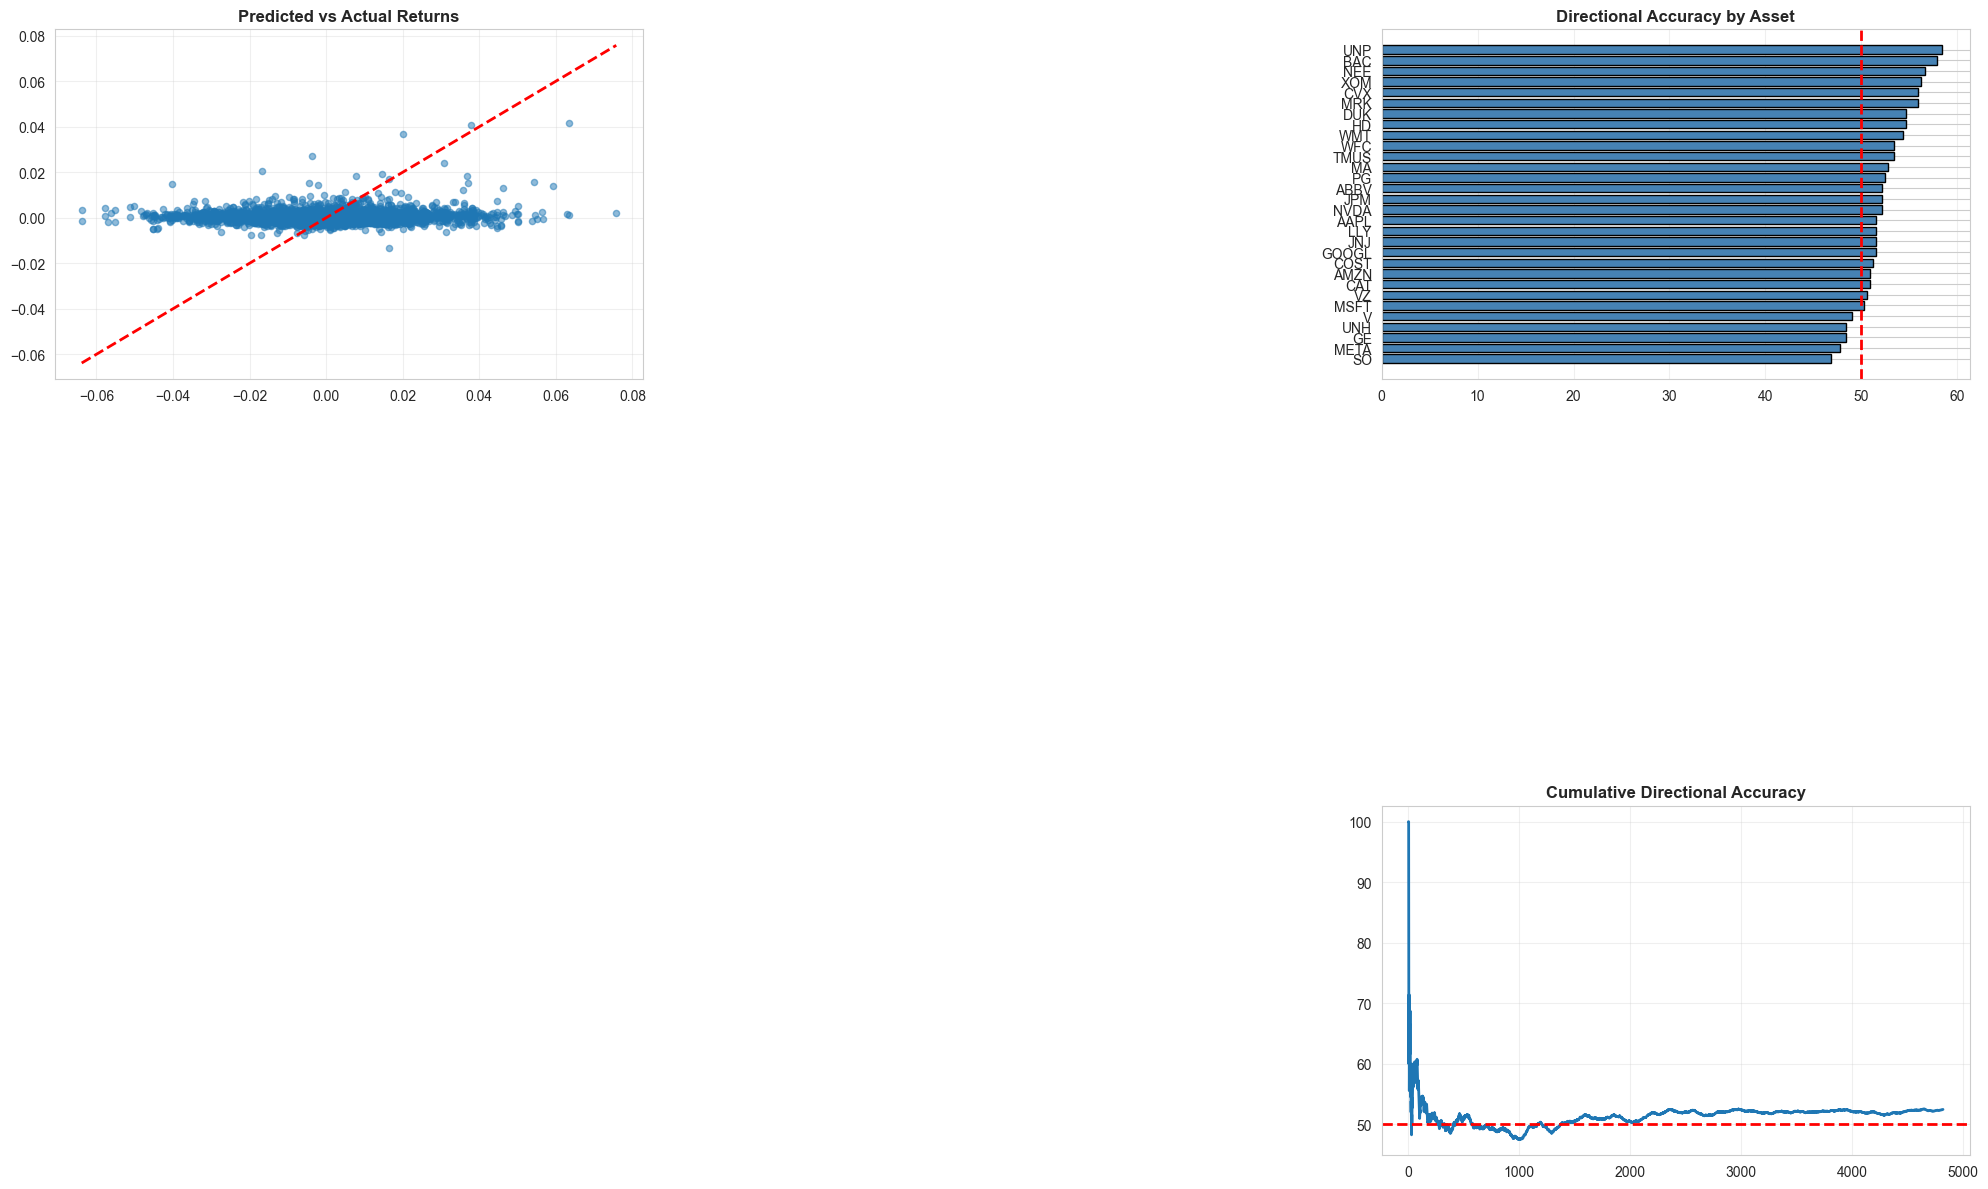

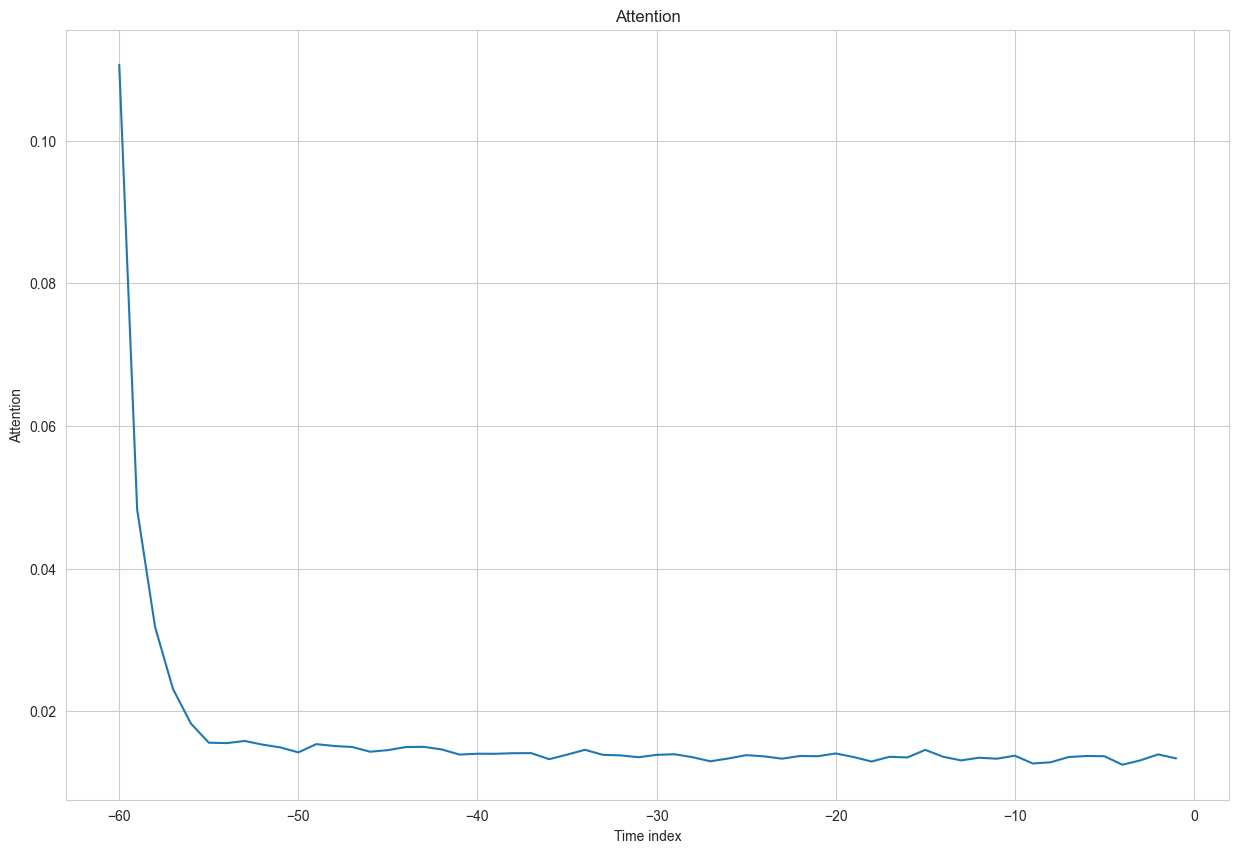

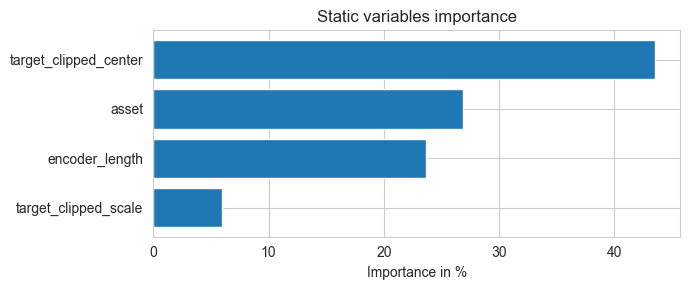

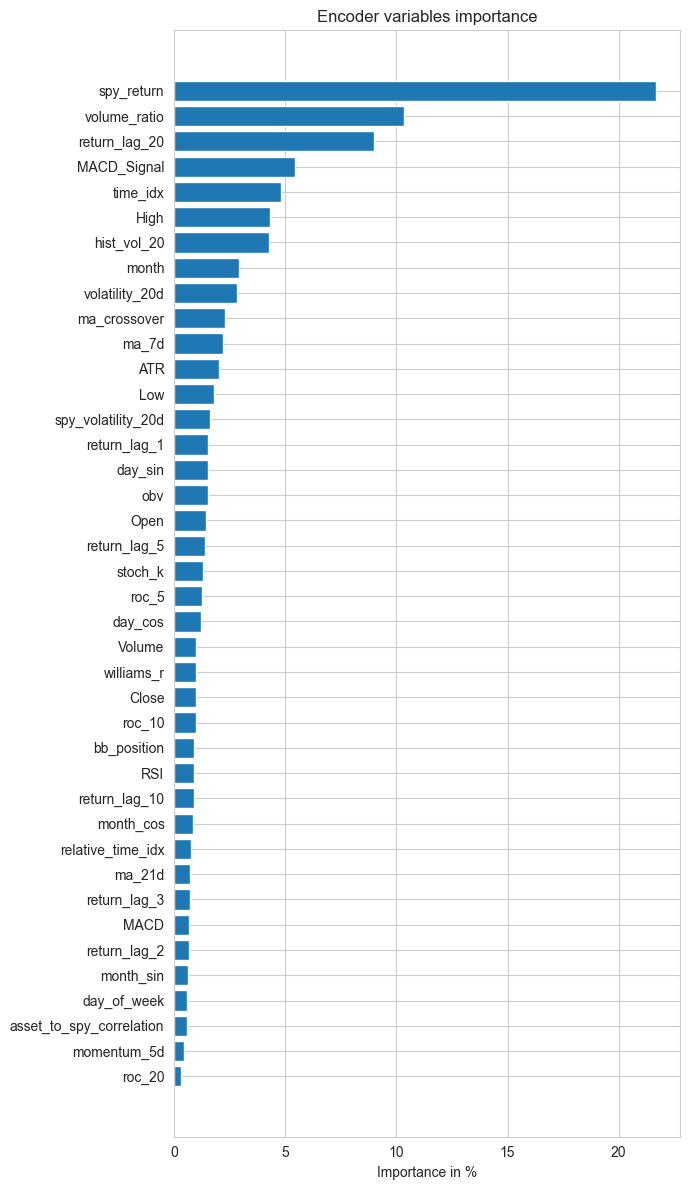

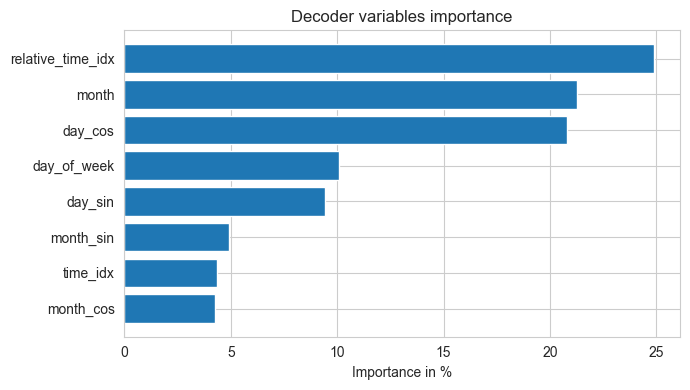

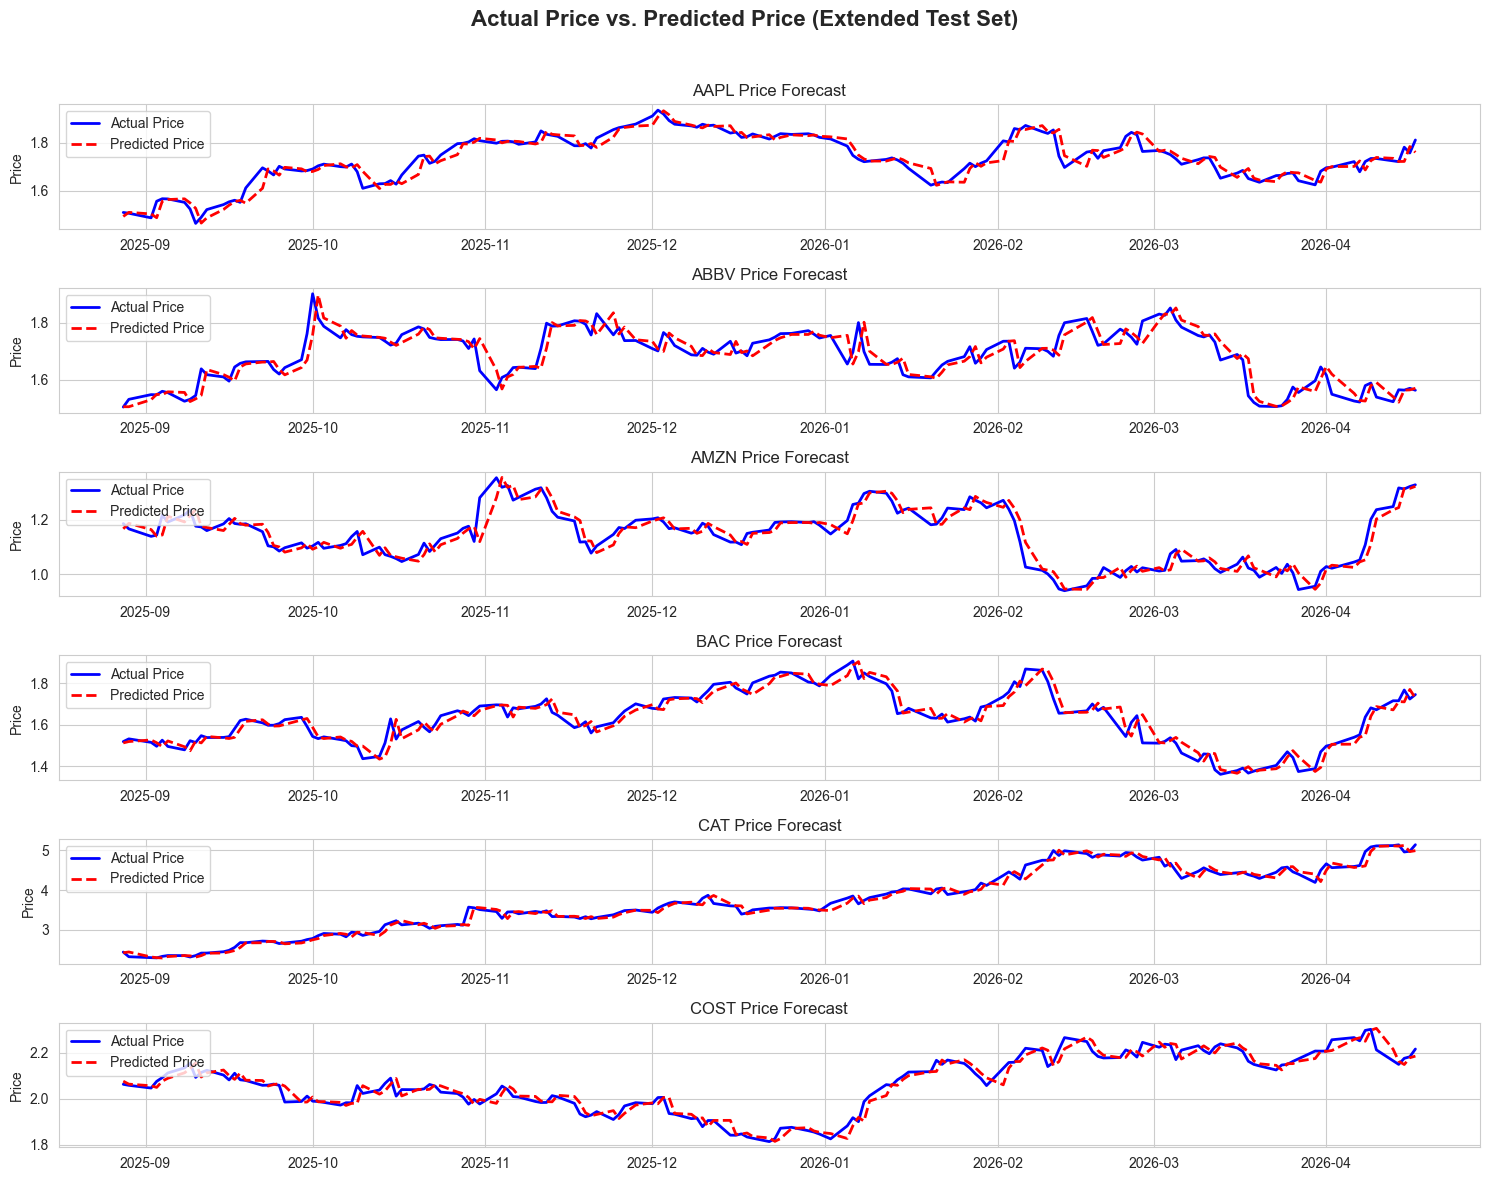

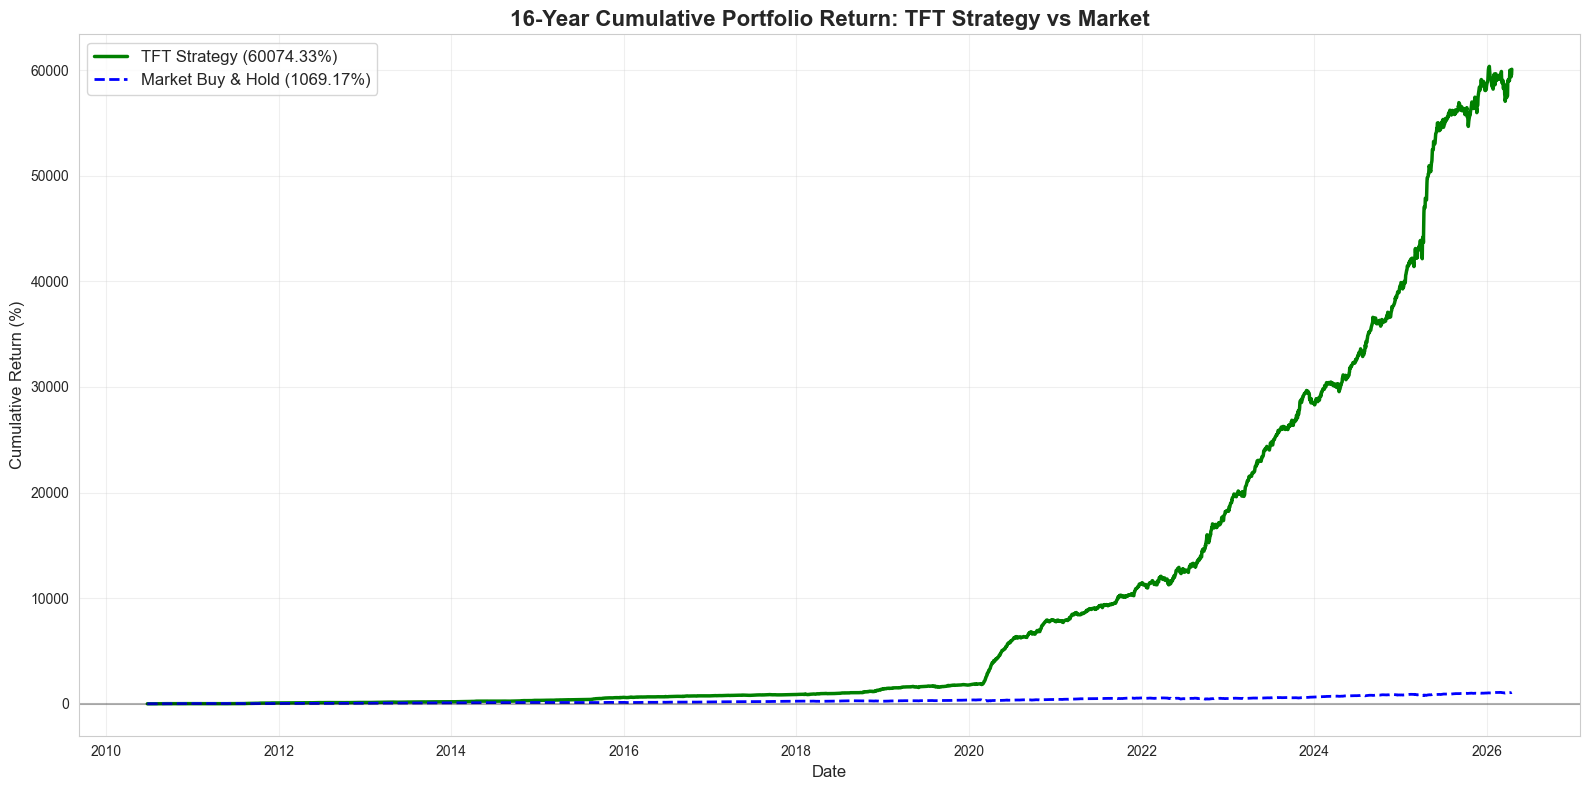

In [10]:
"""
TFT CHAMPION MODEL - ULTIMATE MASTER SCRIPT
Includes: 30 Stocks, Macro Features, 150+ Out-of-Sample Predictions, 
Model Interpretation, Price Forecasts, and Full 16-Year Cumulative Returns.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import lightning.pytorch as pl
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer, NaNLabelEncoder, TemporalFusionTransformer

# 🟢 Disable TQDM widgets to prevent freezing
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="lightning.pytorch")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*70)
print("TFT CHAMPION MODEL - ULTIMATE TEST & BACKTEST PIPELINE")
print("="*70)

# ============================================================================
# STEP 1: Load the trained model
# ============================================================================
print("\n[1/9] Loading trained model...")

best_model_path = r"tft_Fold 3-v1.ckpt" # Make sure this is your best checkpoint!

try:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
    print("✅ Model loaded successfully")
except FileNotFoundError:
    print(f"❌ ERROR: Model checkpoint not found at: {best_model_path}")
    exit()

# ============================================================================
# STEP 2: Recreate dataset & Features (MACRO UPGRADED)
# ============================================================================
print("\n[2/9] Preparing dataset & engineering features...")

max_encoder_length = best_tft.hparams.max_encoder_length
max_prediction_length = 1

print("Loading base dataset 'stock_market_final_30_macro.csv'...")
try:
    df = pd.read_csv('stock_market_final_30_macro.csv')
    df = df[['Date', 'asset', 'target_return', 'Close', 'High', 'Low', 'Open', 'Volume', 
             'RSI', 'MACD', 'MACD_Signal', 'ATR', 
             'spy_return', 'spy_volatility_20d', 'asset_to_spy_correlation']]
except FileNotFoundError:
    print("❌ Error: 'stock_market_final_30_macro.csv' not found.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['asset', 'Date'])

# --- Feature Engineering ---
gb = df.groupby('asset')
df['returns'] = gb['Close'].transform(lambda x: x.pct_change())
df['volatility_20d'] = gb['returns'].transform(lambda x: x.rolling(20).std())
df['momentum_5d'] = gb['Close'].transform(lambda x: x.pct_change(5))
df['ma_7d'] = gb['Close'].transform(lambda x: x.rolling(7).mean())
df['ma_21d'] = gb['Close'].transform(lambda x: x.rolling(21).mean())
df['ma_crossover'] = (df['ma_7d'] - df['ma_21d']) / df['Close']

for lag in [1, 2, 3, 5, 10, 20]:
    df[f'return_lag_{lag}'] = gb['target_return'].shift(lag)
    
for period in [5, 10, 20]:
    df[f'roc_{period}'] = gb['Close'].transform(lambda x: x.pct_change(periods=period))
    
high_14 = gb['High'].transform(lambda x: x.rolling(14).max())
low_14 = gb['Low'].transform(lambda x: x.rolling(14).min())
df['stoch_k'] = (df['Close'] - low_14) / (high_14 - low_14 + 1e-8) * 100
df['williams_r'] = (high_14 - df['Close']) / (high_14 - low_14 + 1e-8) * -100

rolling_mean = gb['Close'].transform(lambda x: x.rolling(20).mean())
rolling_std = gb['Close'].transform(lambda x: x.rolling(20).std())
df['bb_position'] = (df['Close'] - (rolling_mean - 2 * rolling_std)) / (4 * rolling_std + 1e-8)
df['hist_vol_20'] = gb['target_return'].transform(lambda x: x.rolling(20).std() * np.sqrt(252))

df['volume_ratio'] = df['Volume'] / (gb['Volume'].transform(lambda x: x.rolling(20).mean()) + 1e-8)
df['obv'] = gb.apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).cumsum(), include_groups=False).reset_index(level=0, drop=True)

df['day_sin'] = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 5)
df['day_cos'] = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 5)
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

df['target_clipped'] = gb['target_return'].transform(lambda x: x.clip(x.quantile(0.01), x.quantile(0.99)))

KNOWN_REALS = ["time_idx", "day_sin", "day_cos", "month_sin", "month_cos"]
UNKNOWN_REALS = [
    "Close", "High", "Low", "Open", "Volume",
    "RSI", "MACD", "MACD_Signal", "ATR",
    "volatility_20d", "momentum_5d", "ma_7d", "ma_21d", "ma_crossover",
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5", "return_lag_10", "return_lag_20",
    "roc_5", "roc_10", "roc_20", "stoch_k", "williams_r",
    "bb_position", "hist_vol_20", "volume_ratio", "obv",
    "spy_return", "spy_volatility_20d", "asset_to_spy_correlation"
]

# Ensure float and scale
df[UNKNOWN_REALS] = df[UNKNOWN_REALS].astype(float)
for asset in df['asset'].unique():
    scaler = RobustScaler()
    mask = df['asset'] == asset
    df.loc[mask, UNKNOWN_REALS] = scaler.fit_transform(df.loc[mask, UNKNOWN_REALS])

df = df.dropna().reset_index(drop=True)

df['time_idx'] = df.groupby('asset').cumcount()
df['month'] = df['Date'].dt.month.astype(str).astype("category")
df['day_of_week'] = df['Date'].dt.dayofweek.astype(str).astype("category")
df['asset'] = df['asset'].astype("category")

# 🟢 SPLIT AT JUNE 1, 2025 TO GET ~150 SAMPLES PER ASSET
TRAIN_END_DATE = pd.to_datetime("2025-06-01")
print(f"Creating extended test set (all data after {TRAIN_END_DATE.date()})")
train_df = df[df['Date'] <= TRAIN_END_DATE]
test_df = df[df['Date'] > TRAIN_END_DATE]

training_data = TimeSeriesDataSet(
    train_df, time_idx="time_idx", target="target_clipped", group_ids=["asset"],
    max_encoder_length=max_encoder_length, max_prediction_length=max_prediction_length,
    static_categoricals=["asset"], 
    time_varying_known_categoricals=["month", "day_of_week"],
    time_varying_known_reals=KNOWN_REALS,
    time_varying_unknown_reals=UNKNOWN_REALS,
    target_normalizer=GroupNormalizer(groups=["asset"], method="standard", transformation=None, center=True),
    categorical_encoders={"month": NaNLabelEncoder(add_nan=True), "day_of_week": NaNLabelEncoder(add_nan=True)},
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
)

test_data = TimeSeriesDataSet.from_dataset(training_data, test_df, predict=False, stop_randomization=True)

print(f"✅ Training samples: {len(training_data)}")
print(f"✅ Final Test samples: {len(test_data)}")

# ============================================================================
# STEP 3: Make predictions
# ============================================================================
print("\n[3/9] Making predictions on final test set...")

BATCH_SIZE = 64
test_dataloader = test_data.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

# 1. Predictions for Metrics (Quantiles)
prediction_output = best_tft.predict(
    test_dataloader, mode="quantiles", return_index=True, return_y=True,
    trainer_kwargs=dict(accelerator="auto", enable_progress_bar=False)
)

# 2. Predictions for Interpretation (Raw)
raw_output_dict = best_tft.predict(
    test_dataloader, mode="raw", return_x=True,
    trainer_kwargs=dict(accelerator="auto", enable_progress_bar=False)
)

print("✅ Got predictions and raw output for interpretation.")

predictions = prediction_output.output[:, :, 1].cpu().flatten().numpy()
actuals = prediction_output.y[0].cpu().flatten().numpy()
val_index = prediction_output.index

print(f"✅ Generated {len(predictions)} total predictions.")

# ============================================================================
# STEP 4: Calculate metrics
# ============================================================================
print("\n[4/9] Calculating performance metrics...")

results_df = pd.DataFrame({
    'asset': val_index['asset'],
    'time_idx': val_index['time_idx'],
    'actual_return': actuals,
    'predicted_return': predictions
})

results_df = results_df.merge(test_df[['asset', 'time_idx', 'Date', 'Close']], on=['asset', 'time_idx'], how='left')

results_df['actual_direction'] = np.sign(results_df['actual_return'])
results_df['predicted_direction'] = np.sign(results_df['predicted_return'])
results_df['correct_direction'] = (results_df['actual_direction'] == results_df['predicted_direction']).astype(int)
non_zero_mask = (results_df['actual_direction'] != 0) & (results_df['predicted_direction'] != 0)

mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)
overall_hit_rate = results_df[non_zero_mask]['correct_direction'].mean() if non_zero_mask.sum() > 0 else 0.0

print("\n" + "="*70)
print("FINAL MODEL - OVERALL PERFORMANCE METRICS")
print("="*70)
print(f"Mean Squared Error (MSE):     {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE):    {mae:.6f}")
print(f"Directional Accuracy (Hit Rate): {overall_hit_rate * 100:.2f}%")
print(f"Total Predictions:            {len(predictions)}")

asset_metrics = []
for asset in sorted(results_df['asset'].unique()):
    asset_mask = (results_df['asset'] == asset)
    asset_data = results_df[asset_mask]
    asset_non_zero_mask = non_zero_mask & asset_mask
    
    asset_mae = mean_absolute_error(asset_data['actual_return'], asset_data['predicted_return'])
    asset_rmse = np.sqrt(mean_squared_error(asset_data['actual_return'], asset_data['predicted_return']))
    asset_hit_rate = results_df[asset_non_zero_mask]['correct_direction'].mean() if asset_non_zero_mask.sum() > 0 else 0.0
    
    asset_metrics.append({
        'Asset': asset, 'MAE': asset_mae, 'RMSE': asset_rmse,
        'Hit Rate (%)': asset_hit_rate * 100, 'N Predictions': len(asset_data)
    })

# ============================================================================
# STEP 5: Visualization
# ============================================================================
print("\n[5/9] Creating core visualizations...")
fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(3, 3, 1)
ax1.scatter(actuals, predictions, alpha=0.5, s=20)
ax1.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--', lw=2)
ax1.set_title('Predicted vs Actual Returns', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
metrics_df_sorted = pd.DataFrame(asset_metrics).sort_values('Hit Rate (%)', ascending=True)
ax3.barh(metrics_df_sorted['Asset'], metrics_df_sorted['Hit Rate (%)'], color='steelblue', edgecolor='black')
ax3.axvline(x=50, color='r', linestyle='--', linewidth=2)
ax3.set_title('Directional Accuracy by Asset', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

ax9 = plt.subplot(3, 3, 9)
if non_zero_mask.sum() > 0:
    results_df_sorted = results_df[non_zero_mask].sort_values('time_idx').reset_index(drop=True)
    cumulative_correct = results_df_sorted['correct_direction'].cumsum()
    cumulative_total = range(1, len(cumulative_correct) + 1)
    cumulative_rate = (cumulative_correct / pd.Series(cumulative_total)) * 100
    ax9.plot(cumulative_rate, linewidth=2)
    ax9.axhline(y=50, color='r', linestyle='--', linewidth=2)
    ax9.set_title('Cumulative Directional Accuracy', fontsize=12, fontweight='bold')
    ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tft_prediction_analysis_extended.png', dpi=300, bbox_inches='tight')

# ============================================================================
# STEP 6: Model Interpretation (RESTORED!)
# ============================================================================
print("\n[6/9] Analyzing model interpretation (Attention & Features)...")

try:
    interpretation = best_tft.interpret_output(raw_output_dict[0], reduction="sum")
    
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (TOP 10)")
    print("="*70)
    
    if 'encoder_variables' in interpretation:
        # Map indices to feature names
        feature_names = best_tft.encoder_variables
        importance = interpretation['encoder_variables'].cpu().numpy()
        feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
        print(feat_imp.head(10))
        
        fig_interp = best_tft.plot_interpretation(interpretation)
        for f in fig_interp.values():
            if isinstance(f, plt.Figure):
                f.savefig("tft_model_interpretation.png", dpi=300, bbox_inches='tight')
                break
        print("✅ Interpretation plot saved to 'tft_model_interpretation.png'")
        
except Exception as e:
    print(f"⚠️ Could not generate interpretation: {e}")

# ============================================================================
# STEP 7: Save Detailed Results (RESTORED!)
# ============================================================================
print("\n[7/9] Saving detailed results...")
results_df.to_csv('tft_detailed_predictions_extended.csv', index=False)

summary = {
    'Overall MSE': mse, 'Overall RMSE': rmse, 'Overall MAE': mae,
    'Overall Hit Rate (%)': overall_hit_rate * 100,
    'Total Predictions': len(predictions),
    'Non-zero Predictions': non_zero_mask.sum()
}
pd.DataFrame([summary]).to_csv('tft_summary_metrics_extended.csv', index=False)

# ============================================================================
# STEP 8: Plot Predicted Price vs. Actual Price (RESTORED!)
# ============================================================================
print("\n[8/9] Creating price forecast visualization...")
results_df['previous_close'] = results_df.groupby('asset')['Close'].shift(1)
results_df['predicted_price'] = results_df['previous_close'] * (1 + results_df['predicted_return'])
plot_df = results_df.dropna(subset=['previous_close'])

plt.figure(figsize=(15, 12))
plt.suptitle('Actual Price vs. Predicted Price (Extended Test Set)', fontsize=16, fontweight='bold', y=0.98)
assets = sorted(plot_df['asset'].unique())

# Plot the top 6 assets alphabetically just to save space in the image
for i, asset in enumerate(assets[:6]):
    ax = plt.subplot(6, 1, i + 1)
    asset_data = plot_df[plot_df['asset'] == asset].sort_values('Date')
    
    sns.lineplot(data=asset_data, x='Date', y='Close', label='Actual Price', ax=ax, color='blue', linewidth=2)
    sns.lineplot(data=asset_data, x='Date', y='predicted_price', label='Predicted Price', ax=ax, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{asset} Price Forecast', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Price')
    ax.legend(loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('tft_price_forecast_vs_actual.png', dpi=300)
print("✅ Price forecast plot saved to 'tft_price_forecast_vs_actual.png'")

# ============================================================================
# STEP 9: FULL DATASET BACKTEST (2010 - 2026) (NEW!)
# ============================================================================
print("\n[9/9] Running Strategy Backtest on the ENTIRE 16-Year Dataset...")

# Create a dataloader for the entire history
full_data = TimeSeriesDataSet.from_dataset(training_data, df, predict=False, stop_randomization=True)
full_dataloader = full_data.to_dataloader(train=False, batch_size=BATCH_SIZE*2, num_workers=0)

full_pred_output = best_tft.predict(
    full_dataloader, mode="quantiles", return_index=True, return_y=True,
    trainer_kwargs=dict(accelerator="auto", enable_progress_bar=False)
)

full_preds = full_pred_output.output[:, :, 1].cpu().flatten().numpy()
full_actuals = full_pred_output.y[0].cpu().flatten().numpy()
full_idx = full_pred_output.index

full_results_df = pd.DataFrame({
    'asset': full_idx['asset'], 'time_idx': full_idx['time_idx'],
    'actual_return': full_actuals, 'predicted_return': full_preds
})

full_results_df = full_results_df.merge(df[['asset', 'time_idx', 'Date']], on=['asset', 'time_idx'], how='left')

# Portfolio Calculations
full_results_df['position'] = np.sign(full_results_df['predicted_return'])
full_results_df['strategy_return'] = full_results_df['position'] * full_results_df['actual_return']

portfolio_daily = full_results_df.groupby('Date')[['actual_return', 'strategy_return']].mean().reset_index()
portfolio_daily['Cumulative_Market_Return'] = (1 + portfolio_daily['actual_return']).cumprod() - 1
portfolio_daily['Cumulative_Strategy_Return'] = (1 + portfolio_daily['strategy_return']).cumprod() - 1

total_market_return = portfolio_daily['Cumulative_Market_Return'].iloc[-1]
total_strategy_return = portfolio_daily['Cumulative_Strategy_Return'].iloc[-1]

print("\n" + "="*70)
print("HISTORICAL 16-YEAR PORTFOLIO RETURNS (2010 - 2026)")
print("="*70)
print(f"Total Market Return (Buy & Hold):  {total_market_return * 100:.2f}%")
print(f"Total Strategy Return (TFT Model): {total_strategy_return * 100:.2f}%")
if total_strategy_return > total_market_return:
    print("✅ Strategy CRUSHED the Market History!")
print("="*70)

# Visualize 16-Year Returns
plt.figure(figsize=(16, 8))
plt.plot(portfolio_daily['Date'], portfolio_daily['Cumulative_Strategy_Return'] * 100, 
         label=f'TFT Strategy ({total_strategy_return * 100:.2f}%)', color='green', linewidth=2.5)
plt.plot(portfolio_daily['Date'], portfolio_daily['Cumulative_Market_Return'] * 100, 
         label=f'Market Buy & Hold ({total_market_return * 100:.2f}%)', color='blue', linewidth=2, linestyle='--')

plt.title('16-Year Cumulative Portfolio Return: TFT Strategy vs Market', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tft_16_year_backtest.png', dpi=300)
print("✅ 16-Year Backtest Plot saved to 'tft_16_year_backtest.png'")

print("\n" + "="*70)
print("✅ ULTIMATE TEST & BACKTEST COMPLETE!")
print("="*70)